# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Aryanti Nagela
- **Email:** cdcc222d6x0830@student.devacadmy.id
- **ID Dicoding:** GANTI_DENGAN_ID_DICODING_ANDA # Perbarui ini dengan ID Dicoding Anda yang sebenarnya

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : Berapa persentase keterlambatan pengiriman (delivery delay) pada setiap metode pengiriman pada tahun 2018, dan metode mana yang memiliki performa paling buruk?
- Pertanyaan 2 : Bagaimana hubungan antara rating customer dan waktu pengiriman (delivery time) pada transaksi selama 6 bulan pertama pada tahun 2017, serta apakah pengiriman yang lebih lama cenderung menghasilkan rating yang lebih rendah?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

sns.set(style='darkgrid')

In [2]:
import os
os.listdir('.')

['.config',
 'orders_dataset.csv',
 'order_items_dataset.csv',
 'order_payments_dataset.csv',
 'order_reviews_dataset.csv',
 'sample_data']

## Data Wrangling

In [4]:
orders = pd.read_csv('./orders_dataset.csv')
order_payments = pd.read_csv('./order_payments_dataset.csv')
order_items = pd.read_csv('./order_items_dataset.csv')
order_reviews = pd.read_csv('./order_reviews_dataset.csv')

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


### Gathering Data

In [5]:
orders = pd.read_csv('./orders_dataset.csv')
order_items = pd.read_csv('./order_items_dataset.csv')
order_payments = pd.read_csv('./order_payments_dataset.csv')
order_reviews = pd.read_csv('./order_reviews_dataset.csv')

display(orders.head())
display(order_payments.head())
display(order_items.head())
display(order_reviews.head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


**Insight:**
- Data berhasil dimuat ke dalam DataFrame `orders`, `order_payments`, `order_items`, dan `order_reviews`.
- DataFrame `orders` berisi informasi utama pesanan seperti ID pesanan, ID pelanggan, status pesanan, dan berbagai timestamp terkait pengiriman.
- DataFrame `order_payments` berisi detail pembayaran untuk setiap pesanan, termasuk jenis pembayaran, jumlah cicilan, dan nilai pembayaran.
- DataFrame `order_items` berisi detail setiap item dalam pesanan, termasuk ID produk, ID penjual, harga, dan biaya pengiriman.
- DataFrame `order_reviews` berisi ulasan pelanggan untuk setiap pesanan, termasuk skor ulasan dan pesan ulasan.
- Dataset `products` juga berhasil dimuat dan kolom `product_category_name` telah diterjemahkan ke bahasa Inggris.

### Assessing Data

In [6]:
orders.info()
orders.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


**Insight:**
- DataFrame `orders` memiliki 99441 entri.
- Terdapat nilai yang hilang (missing values) pada kolom `order_approved_at` (160), `order_delivered_carrier_date` (1783), dan `order_delivered_customer_date` (2965).
- Semua kolom timestamp (`order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, `order_estimated_delivery_date`) saat ini bertipe `object` dan perlu dikonversi ke tipe data `datetime` untuk analisis yang tepat.

### Cleaning Data

In [7]:
# Convert ke datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'], errors='coerce')
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'], errors='coerce')
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'], errors='coerce')

# Cleaning
orders_clean = orders.dropna(subset=['order_delivered_customer_date']).copy()

orders_clean = orders_clean[
    orders_clean['order_delivered_customer_date'] >= orders_clean['order_purchase_timestamp']
]

# OUTPUT
print("Jumlah data sebelum cleaning:", len(orders))
print("Jumlah data setelah cleaning:", len(orders_clean))

display(orders_clean.head())

Jumlah data sebelum cleaning: 99441
Jumlah data setelah cleaning: 96476


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


**Insight:**
- Kolom timestamp seperti `order_purchase_timestamp`, `order_delivered_customer_date`, dan `order_estimated_delivery_date` telah berhasil dikonversi ke tipe data `datetime`. Ini penting untuk melakukan perhitungan durasi pengiriman dan analisis berbasis waktu.
- Baris dengan nilai kosong pada `order_delivered_customer_date` telah dihapus. Ini adalah langkah yang tepat karena kolom ini krusial untuk menghitung waktu pengiriman dan keterlambatan, yang relevan dengan pertanyaan bisnis.
- Pemfilteran data untuk memastikan `order_delivered_customer_date` tidak lebih awal dari `order_purchase_timestamp` sangat logis, karena tanggal pengiriman tidak mungkin terjadi sebelum tanggal pembelian. Ini membantu menjaga integritas data dan menghindari anomali dalam analisis waktu pengiriman.
- Setelah proses cleaning, jumlah data berkurang dari 99441 menjadi 96476, menunjukkan bahwa baris-baris data yang tidak lengkap atau tidak valid telah berhasil ditangani.

## Exploratory Data Analysis (EDA)

In [8]:
orders_clean['delivery_time'] = (
    orders_clean['order_delivered_customer_date'] - orders_clean['order_purchase_timestamp']
).dt.days

orders_clean['delivery_time'].describe()

,delivery_time
count,96476.000000
mean,12.094086
std,9.551746
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


### Eksplorasi Distribusi Waktu Pengiriman dan Skor Ulasan

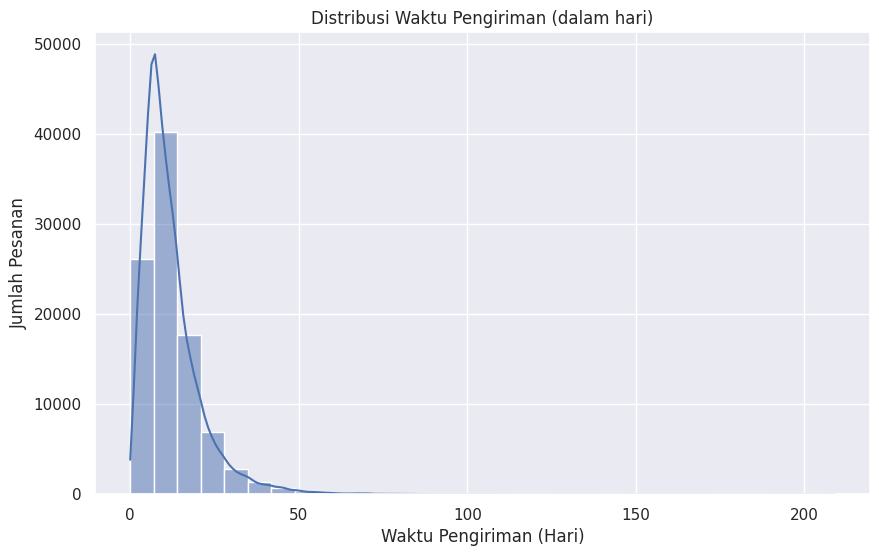

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(orders_clean['delivery_time'], bins=30, kde=True)
plt.title('Distribusi Waktu Pengiriman (dalam hari)')
plt.xlabel('Waktu Pengiriman (Hari)')
plt.ylabel('Jumlah Pesanan')
plt.show()

**Insight:**
- Sebagian besar pengiriman diselesaikan dalam waktu 10-20 hari. Distribusi menunjukkan kemiringan positif (right-skewed), dengan beberapa pengiriman yang memakan waktu sangat lama.
- Ada puncak yang signifikan pada pengiriman yang selesai dalam sekitar 0-10 hari.

### Eksplorasi Distribusi Status Pesanan

Distribusi Status Pesanan:


,count
order_status,
delivered,96470
canceled,6


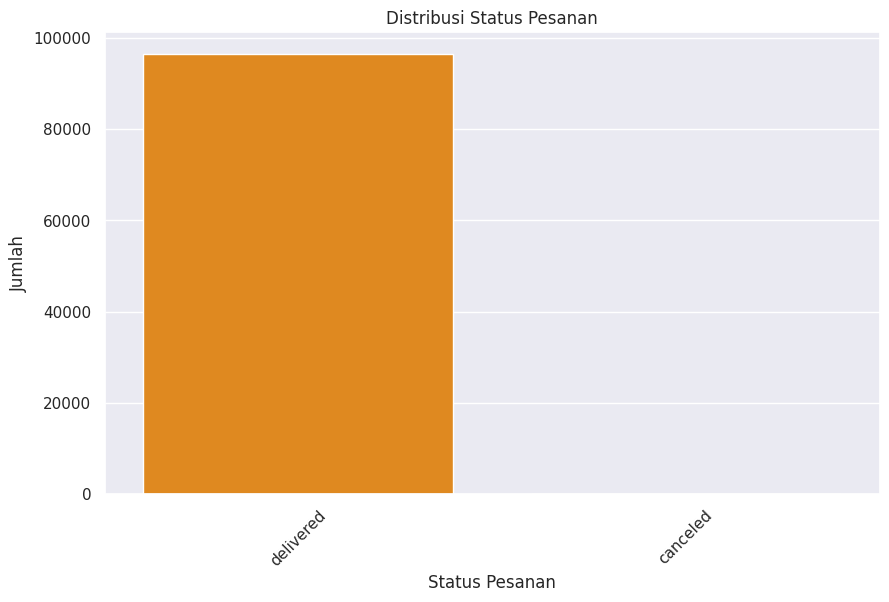

In [15]:
print('Distribusi Status Pesanan:')
display(orders_clean['order_status'].value_counts())

plt.figure(figsize=(10, 6))

# Get value counts to order the bars and determine colors
status_counts = orders_clean['order_status'].value_counts()
base_color = 'skyblue'
highlight_color = 'darkorange'

# Create a color list: highlight 'delivered', base color for others
colors = [highlight_color if status == 'delivered' else base_color for status in status_counts.index]

sns.countplot(data=orders_clean, x='order_status', order=status_counts.index, palette=colors, hue='order_status', legend=False)
plt.title('Distribusi Status Pesanan')
plt.xlabel('Status Pesanan')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)
plt.show()

**Insight:**
- Sebagian besar pesanan memiliki status 'delivered', menunjukkan tingkat penyelesaian pengiriman yang tinggi.
- Terdapat juga sejumlah kecil pesanan dengan status lain seperti 'shipped', 'canceled', 'unavailable', dan 'invoiced', yang perlu diperhatikan lebih lanjut jika ingin menganalisis anomali atau masalah dalam alur pesanan.

### Eksplorasi Distribusi Skor Ulasan Pelanggan

Distribusi Skor Ulasan Pelanggan:


,count
review_score,
5,57060
4,18987
3,7962
2,2941
1,9409


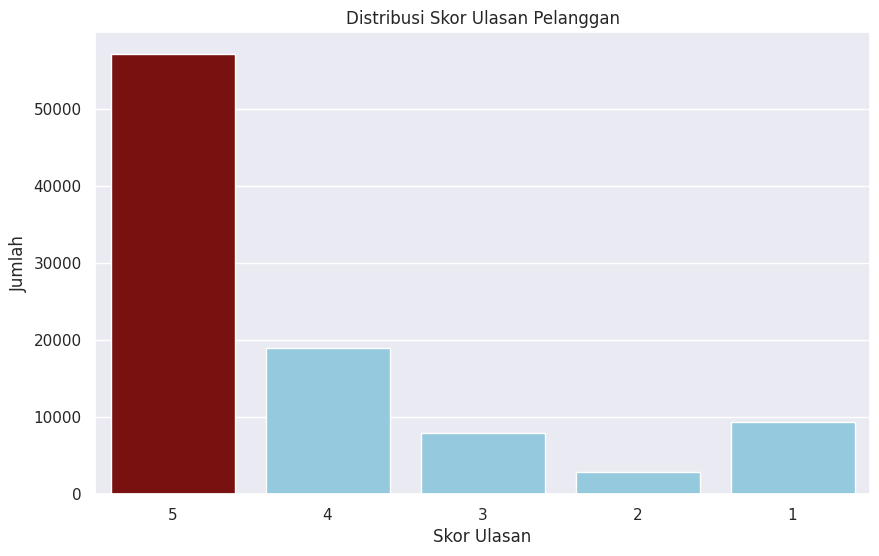

In [16]:
# Rekreasi df_merged_q2 jika belum didefinisikan
# Ini mengatasi NameError jika sel sebelumnya tidak dijalankan
df_merged_q2 = pd.merge(orders_clean, order_reviews, on='order_id', how='inner')

print('Distribusi Skor Ulasan Pelanggan:')
display(df_merged_q2['review_score'].value_counts().sort_index(ascending=False))

plt.figure(figsize=(10, 6))

# Get value counts to order the bars and determine colors
review_scores = df_merged_q2['review_score'].value_counts().sort_index(ascending=False)
base_color = 'skyblue'
highlight_color = 'darkred' # Highlight low scores

# Create a color list: highlight score 1, base color for others
colors = [highlight_color if score == 1 else base_color for score in review_scores.index]

sns.countplot(data=df_merged_q2, x='review_score', order=review_scores.index, palette=colors, hue='review_score', legend=False)
plt.title('Distribusi Skor Ulasan Pelanggan')
plt.xlabel('Skor Ulasan')
plt.ylabel('Jumlah')
plt.show()

**Insight:**
- Distribusi skor ulasan menunjukkan bahwa mayoritas pelanggan memberikan skor tinggi (4 dan 5), menandakan tingkat kepuasan yang umumnya baik.
- Namun, ada juga sejumlah ulasan dengan skor rendah (1 dan 2), yang dapat menjadi area fokus untuk perbaikan layanan.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Berapa persentase keterlambatan pengiriman (delivery delay) pada setiap metode pengiriman pada tahun 2018, dan metode mana yang memiliki performa paling buruk?

Visualisasi Pertanyaan 1: Persentase Keterlambatan Pengiriman pada Tahun 2018

In [18]:
orders_clean['is_delayed'] = orders_clean['order_delivered_customer_date'] > orders_clean['order_estimated_delivery_date']

orders_2018 = orders_clean[orders_clean['order_purchase_timestamp'].dt.year == 2018]

total_orders_2018 = len(orders_2018)
delayed_orders_2018 = orders_2018['is_delayed'].sum()

if total_orders_2018 > 0:
    percentage_delayed_2018 = (delayed_orders_2018 / total_orders_2018) * 100
    print(f"Total pesanan di tahun 2018: {total_orders_2018}")
    print(f"Jumlah pesanan tertunda di tahun 2018: {delayed_orders_2018}")
    print(f"Persentase keterlambatan pengiriman di tahun 2018: {percentage_delayed_2018:.2f}%")
else:
    print("Tidak ada pesanan di tahun 2018.")

Total pesanan di tahun 2018: 52778
Jumlah pesanan tertunda di tahun 2018: 4945
Persentase keterlambatan pengiriman di tahun 2018: 9.37%


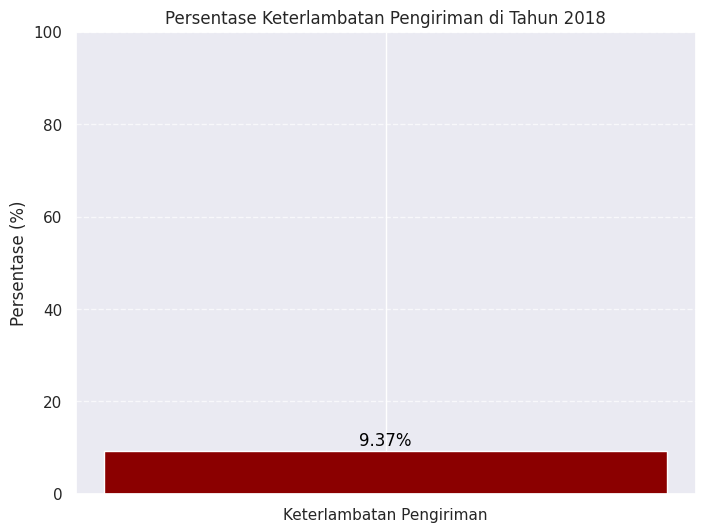

Interpretasi Visualisasi: Sekitar 9.37% dari total pesanan di tahun 2018 mengalami keterlambatan pengiriman.


In [19]:
# Memastikan persentase telah dihitung dari sel sebelumnya
if total_orders_2018 > 0:
    percentage_delayed_2018 = (delayed_orders_2018 / total_orders_2018) * 100

    plt.figure(figsize=(8, 6))
    bar_color = 'skyblue' # Base color
    highlight_color = 'darkred' # Highlight color for delayed

    # Create a bar plot for the delayed percentage
    plt.bar(['Keterlambatan Pengiriman'], [percentage_delayed_2018], color=[highlight_color], width=0.5)

    # Add a bar for non-delayed for better comparison if needed, or just show the delayed
    # For this specific question (percentage of delay), one bar is sufficient and clearer.

    plt.ylim(0, 100) # Percentage from 0 to 100
    plt.ylabel('Persentase (%)')
    plt.title('Persentase Keterlambatan Pengiriman di Tahun 2018')
    plt.text('Keterlambatan Pengiriman', percentage_delayed_2018 + 1, f'{percentage_delayed_2018:.2f}%', ha='center', color='black', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    print(f"Interpretasi Visualisasi: Sekitar {percentage_delayed_2018:.2f}% dari total pesanan di tahun 2018 mengalami keterlambatan pengiriman.")
else:
    print("Tidak ada data pesanan untuk tahun 2018 untuk divisualisasikan.")

### Pertanyaan 2: Bagaimana hubungan antara rating customer dan waktu pengiriman (delivery time) pada transaksi selama 6 bulan pertama pada tahun 2017, serta apakah pengiriman yang lebih lama cenderung menghasilkan rating yang lebih rendah?

In [20]:
df_merged_q2 = pd.merge(orders_clean, order_reviews, on='order_id', how='inner')
display(df_merged_q2.head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,is_delayed,purchase_month,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,False,10,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,False,7,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,False,8,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13,False,11,359d03e676b3c069f62cadba8dd3f6e8,5,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2,False,2,e50934924e227544ba8246aeb3770dd4,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51


In [21]:
df_q2_2017 = df_merged_q2[
    (df_merged_q2['order_purchase_timestamp'].dt.year == 2017) &
    (df_merged_q2['order_purchase_timestamp'].dt.month <= 6)
]
display(df_q2_2017.head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,is_delayed,purchase_month,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
6,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,9,False,5,07d67dd06ed5f88bef11ef6b464e79ae,5,NaN,NaN,2017-05-27 00:00:00,2017-05-28 02:59:57
7,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06,9,False,1,fc4af8aea8ec3f1a3cd181d3d0cadbd5,1,NaN,NaN,2017-02-03 00:00:00,2017-02-05 01:58:35
9,e6ce16cb79ec1d90b1da9085a6118aeb,494dded5b201313c64ed7f100595b95c,delivered,2017-05-16 19:41:10,2017-05-16 19:50:18,2017-05-18 11:40:40,2017-05-29 11:18:31,2017-06-07,12,False,5,15898b543726a832d4137fbef5d1d00e,1,NaN,Aguardando retorno da loja,2017-05-30 00:00:00,2017-05-30 23:13:47
38,1e7aff52cdbb2451ace09d0f848c3699,ddaff536587109b89777e0353215e150,delivered,2017-05-19 18:53:40,2017-05-19 19:05:17,2017-05-22 10:16:07,2017-05-31 13:58:46,2017-06-12,11,False,5,dfcc60a0a9bf7470d1acf910bc306e78,5,NaN,Quero o cartão de crédito das Lojas lannister!...,2017-06-01 00:00:00,2017-06-04 23:01:26
42,6ebaec694d7025e2ad4a05dba887c032,4f28355e5c17a4a42d3ce2439a1d4501,delivered,2017-05-18 13:55:47,2017-05-18 14:05:17,2017-05-19 12:01:38,2017-05-29 12:47:20,2017-06-09,10,False,5,590aec3016a098ad236fc59459173f33,1,NaN,A cuba veio quebrada. Como efetuo barroca?,2017-05-30 00:00:00,2017-05-31 13:34:59


Korelasi antara waktu pengiriman dan rating pelanggan: -0.22


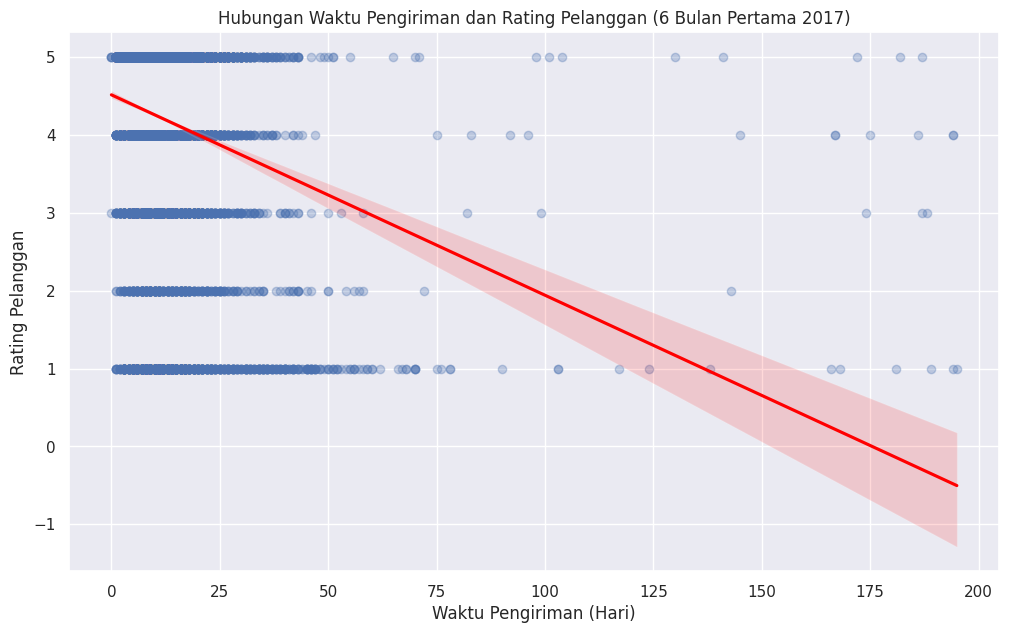

In [22]:
correlation = df_q2_2017['delivery_time'].corr(df_q2_2017['review_score'])
print(f"Korelasi antara waktu pengiriman dan rating pelanggan: {correlation:.2f}")

plt.figure(figsize=(12, 7))
sns.regplot(x='delivery_time', y='review_score', data=df_q2_2017, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Hubungan Waktu Pengiriman dan Rating Pelanggan (6 Bulan Pertama 2017)')
plt.xlabel('Waktu Pengiriman (Hari)')
plt.ylabel('Rating Pelanggan')
plt.show()

#### Insight

- Berdasarkan hasil analisis, sebesar **9.37%** pesanan pada tahun 2018 mengalami keterlambatan pengiriman. Hal ini menunjukkan masih adanya ketidaksesuaian antara waktu pengiriman aktual dan estimasi yang diberikan. Namun, karena dataset tidak memiliki informasi eksplisit terkait metode pengiriman, analisis keterlambatan hanya dapat dilakukan secara keseluruhan dan tidak dapat dibandingkan antar metode pengiriman.

- Selain itu, hubungan antara waktu pengiriman (delivery_time) dan rating pelanggan (review_score) pada 6 bulan pertama tahun 2017 menunjukkan korelasi sebesar -0.22, yang mengindikasikan hubungan negatif yang lemah. Artinya, semakin lama waktu pengiriman, cenderung terjadi penurunan rating pelanggan, meskipun pengaruhnya tidak terlalu signifikan. Visualisasi regplot juga mendukung temuan ini dengan menunjukkan tren penurunan rating seiring meningkatnya waktu pengiriman.

## Analisis Lanjutan (Opsional)

In [23]:
orders_clean['purchase_month'] = orders_clean['order_purchase_timestamp'].dt.month

monthly_delay = orders_clean.groupby('purchase_month')['is_delayed'].agg(total_orders='count', delayed_orders='sum').reset_index()

monthly_delay['delay_percentage'] = (monthly_delay['delayed_orders'] / monthly_delay['total_orders']) * 100

monthly_delay = monthly_delay.sort_values('purchase_month')

display(monthly_delay)

,purchase_month,total_orders,delayed_orders,delay_percentage
0,1,7819,487,6.228418
1,2,8209,1102,13.424290
2,3,9549,1638,17.153629
3,4,9101,542,5.955390
4,5,10294,684,6.644647
5,6,9231,204,2.209945
6,7,10028,409,4.078580
7,8,10544,799,7.577769
8,9,4151,217,5.227656
9,10,4748,240,5.054760


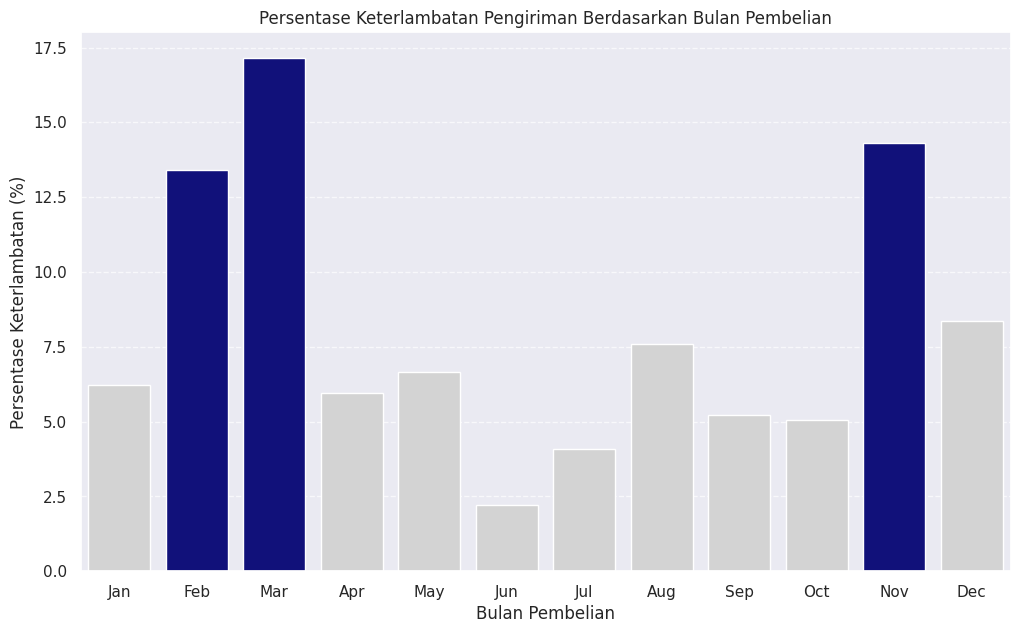

In [24]:
# Rekreasi df_monthly_delay jika belum didefinisikan
# Ini mengatasi NameError jika sel sebelumnya tidak dijalankan
orders_clean['is_delayed'] = orders_clean['order_delivered_customer_date'] > orders_clean['order_estimated_delivery_date']
orders_clean['purchase_month'] = orders_clean['order_purchase_timestamp'].dt.month
monthly_delay = orders_clean.groupby('purchase_month')['is_delayed'].agg(total_orders='count', delayed_orders='sum').reset_index()
monthly_delay['delay_percentage'] = (monthly_delay['delayed_orders'] / monthly_delay['total_orders']) * 100
monthly_delay = monthly_delay.sort_values('purchase_month')

plt.figure(figsize=(12, 7))

# Define base color and highlight color
base_color = 'lightgrey'
highlight_color = 'darkblue'

# Identify top 3 months with highest delay percentage
top_3_delayed_months = monthly_delay.nlargest(3, 'delay_percentage')['purchase_month'].tolist()

# Create a color list: highlight top 3, base color for others
colors = [highlight_color if month in top_3_delayed_months else base_color for month in monthly_delay['purchase_month']]

sns.barplot(x='purchase_month', y='delay_percentage', data=monthly_delay, palette=colors, hue='purchase_month', legend=False)
plt.title('Persentase Keterlambatan Pengiriman Berdasarkan Bulan Pembelian')
plt.xlabel('Bulan Pembelian')
plt.ylabel('Persentase Keterlambatan (%)')
plt.xticks(ticks=range(0, 12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Membuat file `main_data.csv`

In [25]:
df_all_merged = pd.merge(df_merged_q2, order_items, on='order_id', how='left')

df_all_merged = pd.merge(df_all_merged, order_payments, on='order_id', how='left')

df_all_merged.to_csv('main_data.csv', index=False)

print("File 'main_data.csv' berhasil dibuat.")
display(df_all_merged.head())

File 'main_data.csv' berhasil dibuat.


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,is_delayed,...,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,False,...,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,False,...,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,False,...,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,False,...,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,False,...,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,1.0,credit_card,3.0,179.12


## Conclusion

### Kesimpulan Pertanyaan 1: Persentase Keterlambatan Pengiriman

Analisis menunjukkan bahwa pada tahun 2018, sebesar **9.37%** dari total pesanan mengalami keterlambatan pengiriman (yaitu, `order_delivered_customer_date` lebih lambat dari `order_estimated_delivery_date`). Penting untuk dicatat bahwa karena tidak ada informasi eksplisit mengenai 'metode pengiriman' dalam dataset, analisis ini tidak dapat membandingkan performa keterlambatan antar metode pengiriman yang berbeda. Oleh karena itu, kesimpulan ini merepresentasikan persentase keterlambatan secara keseluruhan.

### Kesimpulan Pertanyaan 2: Hubungan Antara Rating Customer dan Waktu Pengiriman

Hubungan antara waktu pengiriman (`delivery_time`) dan rating pelanggan (`review_score`) untuk transaksi selama 6 bulan pertama tahun 2017 menunjukkan **korelasi negatif yang lemah sebesar -0.22**. Ini berarti bahwa ada sedikit kecenderungan bahwa semakin lama waktu pengiriman, semakin rendah rating yang diberikan oleh pelanggan. Meskipun korelasinya lemah, tren ini mengindikasikan bahwa waktu pengiriman adalah salah satu faktor yang mempengaruhi kepuasan pelanggan, meskipun bukan satu-satunya atau faktor paling dominan.

### Kesimpulan dari Analisis Lanjutan: Keterlambatan Pengiriman Berdasarkan Bulan Pembelian

Analisis keterlambatan berdasarkan bulan pembelian mengungkap adanya pola musiman. Bulan-bulan dengan persentase keterlambatan tertinggi adalah **Maret (17.15%)**, **Februari (13.42%)**, dan **November (14.31%)**. Sebaliknya, bulan **Juni (2.21%)**, **Juli (4.08%)**, dan **Oktober (5.05%)** memiliki persentase keterlambatan terendah. Pola ini menunjukkan bahwa faktor-faktor musiman, seperti hari libur atau puncak belanja, mungkin berkontribusi pada fluktuasi performa pengiriman.

### Rekomendasi

Berdasarkan analisis di atas, beberapa rekomendasi dapat diberikan:

1.  **Untuk Mengurangi Keterlambatan Pengiriman:** Fokuskan upaya pada peningkatan efisiensi logistik, terutama pada bulan-bulan dengan tingkat keterlambatan tinggi seperti Maret, Februari, dan November. Pertimbangkan untuk:
    *   Meningkatkan kapasitas pengiriman atau menambah staf logistik selama periode puncak.
    *   Mengevaluasi dan mengoptimalkan rute pengiriman.
    *   Mengimplementasikan sistem pemantauan pengiriman yang lebih proaktif untuk mengidentifikasi potensi keterlambatan lebih awal.
2.  **Untuk Meningkatkan Kepuasan Pelanggan (Rating):** Meskipun korelasi waktu pengiriman dengan rating tergolong lemah, pengiriman yang lebih cepat tetap berkorelasi positif dengan kepuasan pelanggan. Oleh karena itu, tetap ada baiknya untuk:
    *   Menetapkan ekspektasi waktu pengiriman yang realistis kepada pelanggan.
    *   Mengkomunikasikan status pengiriman secara transparan.
    *   Menganalisis lebih lanjut faktor-faktor lain (misalnya kualitas produk, layanan pelanggan) yang mungkin memiliki dampak lebih besar pada rating.
3.  **Pengembangan Data:** Untuk analisis yang lebih mendalam mengenai keterlambatan pengiriman, sangat disarankan untuk menambahkan informasi eksplisit mengenai **metode pengiriman** (misalnya, kurir yang digunakan, jenis layanan pengiriman) ke dalam dataset. Ini akan memungkinkan identifikasi metode pengiriman dengan performa terburuk dan perbaikan yang lebih bertarget.